In [19]:
import yfinance as yf
import pandas as pd

In [2]:
sp500 = yf.Ticker("^GSPC")

In [4]:
sp500 = sp500.history(period="max")

In [5]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-05-15 00:00:00-04:00,7445.109863,7454.850098,7397.500000,7408.500000,5582070000,0.0,0.0
2026-05-18 00:00:00-04:00,7415.069824,7434.060059,7353.169922,7403.049805,5489500000,0.0,0.0
2026-05-19 00:00:00-04:00,7375.750000,7395.319824,7333.680176,7353.609863,5441140000,0.0,0.0


In [6]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-05-08 00:00:00-04:00', '2026-05-11 00:00:00-04:00',
               '2026-05-12 00:00:00-04:00', '2026-05-13 00:00:00-04:00',
               '2026-05-14 00:00:00-04:00', '2026-05-15 00:00:00-04:00',
               '2026-05-18 00:00:00-04:00', '2026-05-19 00:00:00-04:00',
               '2026-05-20 00:00:00-04:00', '2026-05-21 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24714, freq=None)

<Axes: xlabel='Date'>

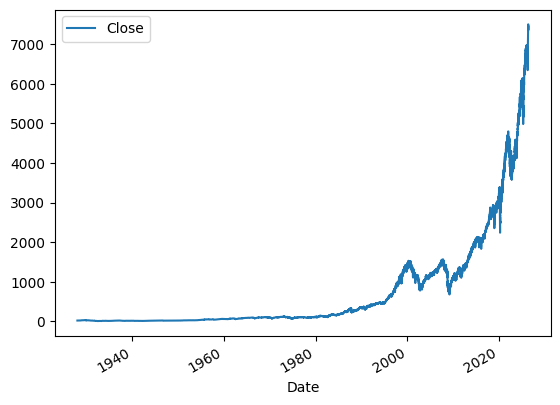

In [7]:
sp500.plot.line(y="Close", use_index=True)

In [9]:
del sp500["Dividends"]
del sp500["Stock Splits"]

In [10]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)

In [11]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-05-15 00:00:00-04:00,7445.109863,7454.850098,7397.500000,7408.500000,5582070000,7403.049805
2026-05-18 00:00:00-04:00,7415.069824,7434.060059,7353.169922,7403.049805,5489500000,7353.609863
2026-05-19 00:00:00-04:00,7375.750000,7395.319824,7333.680176,7353.609863,5441140000,7432.970215


In [12]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)

In [13]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-05-15 00:00:00-04:00,7445.109863,7454.850098,7397.500000,7408.500000,5582070000,7403.049805,0
2026-05-18 00:00:00-04:00,7415.069824,7434.060059,7353.169922,7403.049805,5489500000,7353.609863,0
2026-05-19 00:00:00-04:00,7375.750000,7395.319824,7333.680176,7353.609863,5441140000,7432.970215,1


In [15]:
sp500 = sp500.loc["2005-01-01":].copy()

In [16]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
2005-01-03 00:00:00-05:00,1211.920044,1217.800049,1200.319946,1202.079956,1510800000,1188.050049,0
2005-01-04 00:00:00-05:00,1202.079956,1205.839966,1185.390015,1188.050049,1721000000,1183.739990,0
2005-01-05 00:00:00-05:00,1188.050049,1192.729980,1183.719971,1183.739990,1738900000,1187.890015,1
2005-01-06 00:00:00-05:00,1183.739990,1191.630005,1183.270020,1187.890015,1569100000,1186.189941,0
2005-01-07 00:00:00-05:00,1187.890015,1192.199951,1182.160034,1186.189941,1477900000,1190.250000,1
...,...,...,...,...,...,...,...
2026-05-15 00:00:00-04:00,7445.109863,7454.850098,7397.500000,7408.500000,5582070000,7403.049805,0
2026-05-18 00:00:00-04:00,7415.069824,7434.060059,7353.169922,7403.049805,5489500000,7353.609863,0
2026-05-19 00:00:00-04:00,7375.750000,7395.319824,7333.680176,7353.609863,5441140000,7432.970215,1


In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=500, min_samples_split=100, random_state=1)

train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

RandomForestClassifier(min_samples_split=100, n_estimators=500, random_state=1)

In [21]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)
precision_score(test["Target"], preds)

0.575

<Axes: xlabel='Date'>

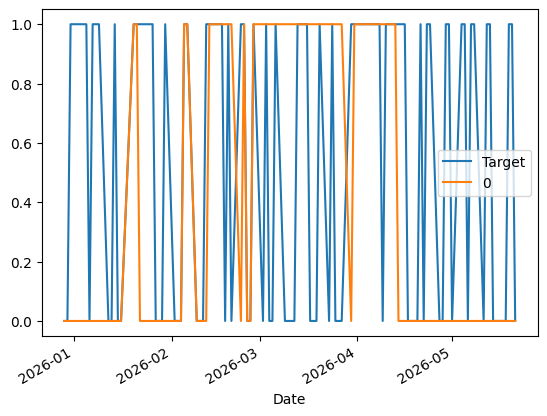

In [22]:
combined = pd.concat([test["Target"], preds], axis=1)
combined.plot()

In [23]:
def predict(train, test, predictors, model):
  model.fit(train[predictors], train["Target"])
  preds = model.predict(test[predictors])
  preds = pd.Series(preds, index=test.index, name="Predictions")
  combined = pd.concat([test["Target"], preds], axis=1)
  return combined

In [24]:
def backtest(data, model, predictors, start=2500, step=250):
  all_predictions = []

  for i in range(start, data.shape[0], step):
    train = data.iloc[0:i].copy()
    test = data.iloc[i:(i+step)].copy()
    predictions = predict(train, test, predictors, model)
    all_predictions.append(predictions)

  return pd.concat(all_predictions)

In [26]:
predictions = backtest(sp500, model, predictors)

In [27]:
predictions["Predictions"].value_counts()

,count
Predictions,
0,1467
1,1413


In [28]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5364472753007785

In [29]:
predictions["Target"].value_counts() / predictions.shape[0]

,count
Target,
1,0.540278
0,0.459722


In [30]:
horizons = [2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
  rolling_averages = sp500.rolling(horizon).mean()

  ratio_column = f"Close_Ratio_{horizon}"
  sp500[ratio_column] = sp500["Close"] / rolling_averages["Close"]

  trend_column = f"Trend_{horizon}"
  sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]

  new_predictors += [ratio_column, trend_column]

In [31]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
2005-01-03 00:00:00-05:00,1211.920044,1217.800049,1200.319946,1202.079956,1510800000,1188.050049,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-04 00:00:00-05:00,1202.079956,1205.839966,1185.390015,1188.050049,1721000000,1183.739990,0,0.994130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-05 00:00:00-05:00,1188.050049,1192.729980,1183.719971,1183.739990,1738900000,1187.890015,1,0.998183,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-06 00:00:00-05:00,1183.739990,1191.630005,1183.270020,1187.890015,1569100000,1186.189941,0,1.001750,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-07 00:00:00-05:00,1187.890015,1192.199951,1182.160034,1186.189941,1477900000,1190.250000,1,0.999284,1.0,0.997142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-15 00:00:00-04:00,7445.109863,7454.850098,7397.500000,7408.500000,5582070000,7403.049805,0,0.993780,1.0,0.996629,3.0,1.071561,33.0,1.114540,141.0,1.412887,542.0
2026-05-18 00:00:00-04:00,7415.069824,7434.060059,7353.169922,7403.049805,5489500000,7353.609863,0,0.999632,0.0,0.996158,2.0,1.069501,32.0,1.112756,140.0,1.410905,541.0
2026-05-19 00:00:00-04:00,7375.750000,7395.319824,7333.680176,7353.609863,5441140000,7432.970215,1,0.996650,0.0,0.990768,2.0,1.061040,32.0,1.104387,140.0,1.400580,540.0


In [32]:
sp500 = sp500.dropna()

In [33]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
2008-12-22 00:00:00-05:00,887.200012,887.369995,857.090027,871.630005,4869850000,863.159973,0,0.990764,1.0,0.976640,2.0,0.944483,25.0,0.707891,123.0,0.667342,541.0
2008-12-23 00:00:00-05:00,874.309998,880.440002,860.099976,863.159973,4051970000,868.150024,1,0.995118,0.0,0.978114,1.0,0.939432,25.0,0.702411,123.0,0.661022,541.0
2008-12-24 00:00:00-05:00,863.869995,869.789978,861.440002,868.150024,1546550000,872.799988,1,1.002882,1.0,0.991922,2.0,0.950002,25.0,0.707878,123.0,0.665004,542.0
2008-12-26 00:00:00-05:00,869.510010,873.739990,866.520020,872.799988,1880050000,869.419983,0,1.002671,2.0,1.000087,3.0,0.960138,26.0,0.713055,124.0,0.668727,542.0
2008-12-29 00:00:00-05:00,872.369995,873.700012,857.070007,869.419983,3323430000,890.640015,1,0.998060,1.0,1.000446,2.0,0.960732,26.0,0.711637,124.0,0.666299,542.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-14 00:00:00-04:00,7454.399902,7517.120117,7454.399902,7501.240234,5267050000,7408.500000,0,1.003813,2.0,1.009365,4.0,1.086407,33.0,1.129478,142.0,1.431531,542.0
2026-05-15 00:00:00-04:00,7445.109863,7454.850098,7397.500000,7408.500000,5582070000,7403.049805,0,0.993780,1.0,0.996629,3.0,1.071561,33.0,1.114540,141.0,1.412887,542.0
2026-05-18 00:00:00-04:00,7415.069824,7434.060059,7353.169922,7403.049805,5489500000,7353.609863,0,0.999632,0.0,0.996158,2.0,1.069501,32.0,1.112756,140.0,1.410905,541.0


In [45]:
model = RandomForestClassifier(n_estimators=250, min_samples_split=50, random_state=1)

def predict(train, test, predictors, model):
  model.fit(train[predictors], train["Target"])

In [46]:
def predict(train, test, predictors, model):
  model.fit(train[predictors], train["Target"])
  preds = model.predict_proba(test[predictors])[:,1]
  preds[preds >= .6] = 1
  preds[preds < .6] = 0
  preds = pd.Series(preds, index=test.index, name="Predictions")
  combined = pd.concat([test["Target"], preds], axis=1)
  return combined

In [47]:
predictions = backtest(sp500, model, new_predictors)

In [48]:
predictions["Predictions"].value_counts()

,count
Predictions,
0.0,1608
1.0,271


In [49]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5793357933579336